In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d,gaussian_filter
import pickle
from skimage import io, filters
import glob
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import psutil
from brainsss import brain_utils

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
fly_num = 'fly_209'
moco_path = 'func_0/moco/functional_channel_2_moco.h5'
bg_path = 'func_0/background_subtraction/functional_channel_2_moco.h5'
warp_path = 'warp/functional_channel_2_moco_warp.h5'
blur_path = 'dff/functional_channel_2_moco_warp_blurred.h5'
hpf_path = 'dff/functional_channel_2_moco_warp_blurred_hpf.h5'
dff_path = 'dff/functional_channel_2_moco_warp_blurred_hpf_dff.h5'
timestamp_file = "warp/timestamps_warp.h5"
ts_file = "func_0/imaging"
temp_filter='temp_filter/functional_channel_2_moco_warp_blurred_hpf_dff_filtered.h5'
func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'
moco_dir = os.path.join(func_path, moco_path)
bg_dir = os.path.join(func_path, bg_path)
warp_dir = os.path.join(func_path, warp_path)
blur_dir = os.path.join(func_path, blur_path)
hpf_dir = os.path.join(func_path, hpf_path)
dff_dir = os.path.join(func_path, dff_path)
og_ts_dir = os.path.join(func_path, ts_file)
ts_dir = os.path.join(func_path, timestamp_file)
filter_dir = os.path.join(func_path, temp_filter)

In [3]:
start=1500
end=1600

In [4]:
%%time
with h5py.File(moco_dir, 'r') as hf:
        brain = hf['data']
        brain = brain[...,start:end]
        dimsb = np.shape(brain)
        print(f"Data shape is {dimsb}")

Data shape is (256, 128, 49, 100)
CPU times: user 128 ms, sys: 787 ms, total: 916 ms
Wall time: 32.1 s


In [5]:
%%time
with h5py.File(bg_dir, 'r') as bf:
        bg = bf['data']
        bg = bg[...,start:end]
        dimsbg = np.shape(bg)
        print(f"Data shape is {dimsbg}")

Data shape is (256, 128, 49, 100)
CPU times: user 96.8 ms, sys: 4.06 s, total: 4.15 s
Wall time: 1min 35s


In [6]:
%%time
with h5py.File(warp_dir, 'r') as wf:
        warp = wf['data']
        warp = warp[...,start:end]
        dimsw = np.shape(warp)
        print(f"Data shape is {dimsw}")

Data shape is (314, 146, 91, 100)
CPU times: user 339 ms, sys: 10.3 s, total: 10.7 s
Wall time: 4min 7s


In [7]:
%%time
with h5py.File(blur_dir, 'r') as df:
        blur = df['data']
        blur = blur[...,start:end]
        dimsd = np.shape(blur)
        print(f"Data shape is {dimsd}")

Data shape is (314, 146, 91, 100)
CPU times: user 318 ms, sys: 10.9 s, total: 11.2 s
Wall time: 2min 20s


In [8]:
%%time
with h5py.File(hpf_dir, 'r') as pf:
        filtered = pf['hpf']
        filtered=filtered[...,start:end]
        dimsf = np.shape(filtered)
        print(f"Data shape is {dimsf}")

Data shape is (314, 146, 91, 100)
CPU times: user 319 ms, sys: 1min 24s, total: 1min 25s
Wall time: 16min 2s


In [9]:
%%time
with h5py.File(dff_dir, 'r') as ff:
        dff = ff['data']
        dff=dff[...,start:end]
        dimsdf = np.shape(dff)
        print(f"Data shape is {dimsdf}")

Data shape is (314, 146, 91, 100)
CPU times: user 206 ms, sys: 5.94 s, total: 6.14 s
Wall time: 1min


In [15]:
%%time
with h5py.File(filter_dir, 'r') as pf:
        tf = pf['brain'][:]
        tsf = pf['time_stamps'][:]
#         tf=tf[...,start:end]
#         tsf=tsf[...,start:end]
        dimstf = np.shape(tf)
        dimstsf = np.shape(tsf)
        print(f"Data shape is {dimstf}, timestamp shape is {dimstsf}")

Data shape is (314, 146, 91, 29), timestamp shape is (314, 146, 91, 29)
CPU times: user 1.88 ms, sys: 601 ms, total: 603 ms
Wall time: 2.45 s


In [10]:
%%time
with h5py.File(ts_dir, 'r') as tf:
        ts = tf['data']
        ts=ts[...,start:end]
        dimsts=np.shape(ts)
        print(f"Data shape is {dimsts}")

Data shape is (314, 146, 91, 100)
CPU times: user 322 ms, sys: 10.3 s, total: 10.6 s
Wall time: 2min 19s


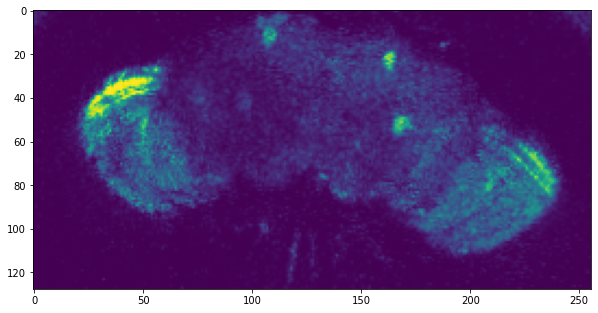

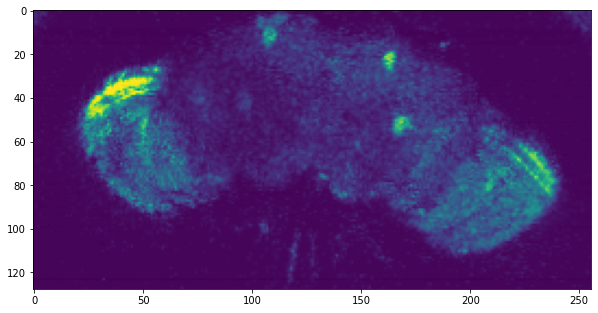

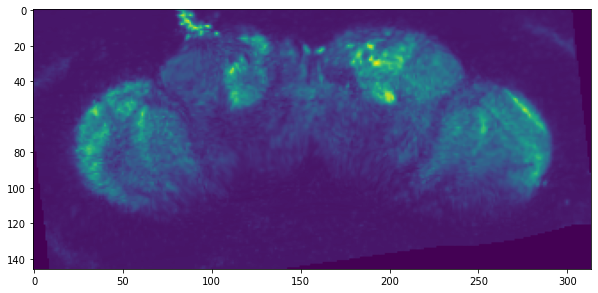

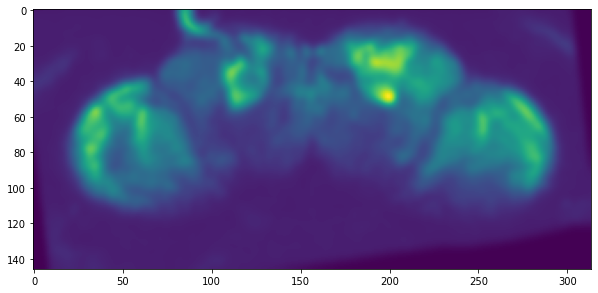

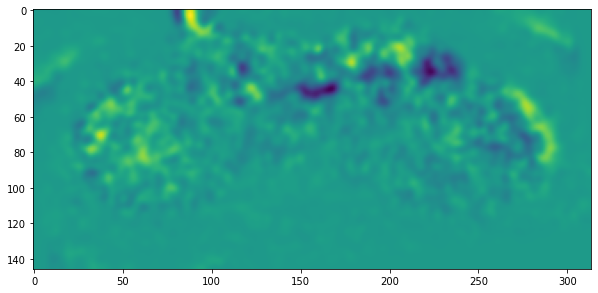

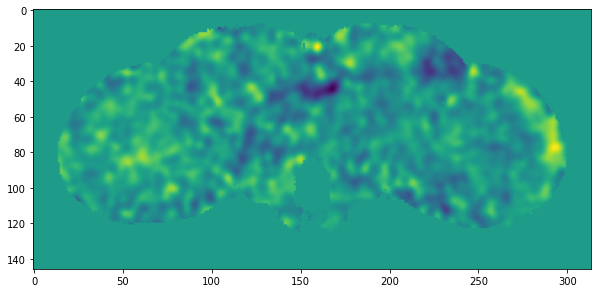

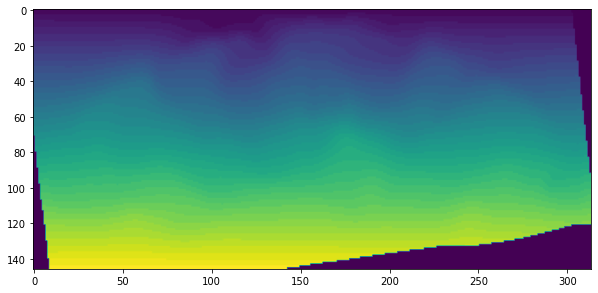

In [16]:
plt.figure(figsize=(10,10))
plt.imshow(brain[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(bg[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(warp[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(blur[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(filtered[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(dff[:,:,20,-1].T)
plt.figure(figsize=(10,10))
plt.imshow(ts[:,:,20,-1].T)